In [ ]:
# ==== THIẾT LẬP 2 MÔI TRƯỜNG (Colab HOẶC Local - VS Code) ====
import sys
from pathlib import Path

def _resolve_project_path():
    # 1) Google Colab: gắn Drive và trả về đường dẫn project trên Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        return '/content/drive/MyDrive/DeTaiHocSauKetHopDoAnTongHop/Stock_Forecasting_Project'
    except ImportError:
        pass
    # 2) Local (VS Code): đi ngược lên tìm thư mục gốc chứa 01_Data/
    p = Path.cwd()
    while not (p / '01_Data').exists() and p != p.parent:
        p = p.parent
    return str(p)

PROJECT_PATH = _resolve_project_path()
sys.path.append(PROJECT_PATH + '/04_Source_Code')
print('PROJECT_PATH =', PROJECT_PATH)


In [ ]:
# ==== CÀI THƯ VIỆN (chỉ cần trên Colab; Local đã có .venv) ====
import sys as _sys
if 'google.colab' in _sys.modules:
    get_ipython().system('pip -q install pandas numpy scikit-learn matplotlib torch streamlit plotly joblib yfinance')
    print('Đã cài thư viện cho Colab.')
else:
    print('Local: dùng sẵn .venv của project — bỏ qua cài đặt.')


In [16]:
# 2. NẠP VÀ XỬ LÝ DỮ LIỆU (Đã sửa lỗi Multi-step Target)
import importlib
import feature_engineering
importlib.reload(feature_engineering)
from data_ingestion import DataIngestor
from feature_engineering import FeatureEngineer

ingestor = DataIngestor(ticker='FPT.VN', start_date='2020-01-01', end_date='2024-01-01')
# Forecast_horizon mặc định là 3 để khớp với Model
engineer = FeatureEngineer(window_size=30, forecast_horizon=3)

df_raw = ingestor.fetch_stock_data()
df_features = engineer.add_indicators(df_raw)

feature_cols = ['Close', 'RSI', 'Log_Ret']
X, y = engineer.create_sliding_windows(df_features, feature_cols)
X_train, X_test, y_train, y_test = engineer.time_series_split(X, y)

print(f"✅ Đã chuẩn bị dữ liệu mới!")
print(f"X_test shape: {X_test.shape} (Cần 30 steps, 3 features)")
print(f"y_test shape: {y_test.shape} (Cần 3 cột nhãn cho 3 ngày)")

[*********************100%***********************]  1 of 1 completed

Fetching data for FPT.VN...
✅ Đã chuẩn bị dữ liệu mới!
X_test shape: (197, 30, 3) (Cần 30 steps, 3 features)
y_test shape: (197, 3) (Cần 3 cột nhãn cho 3 ngày)


In [17]:
# 3. HUẤN LUYỆN MÔ HÌNH (Ép nạp lại Class & Huấn luyện Multi-step)
import sys
import importlib
import numpy as np

# Bước quan trọng: Xóa cache của module để nhận diện tham số forecast_horizon mới
if 'model_architecture' in sys.modules:
    del sys.modules['model_architecture']

import model_architecture
from model_architecture import DataFusionModel

print("🔄 Hệ thống đã nạp bản cập nhật: DataFusionModel(forecast_horizon=3)")

# Khởi tạo mô hình dự báo 3 ngày
fusion_model = DataFusionModel(sequence_length=30, n_features=3, nlp_dim=3, forecast_horizon=3)
model = fusion_model.build_model()

# Chuẩn bị dữ liệu đầu vào NLP giả lập (vì chúng ta đang tập trung vào Price Action)
nlp_train = np.zeros((X_train.shape[0], 3))

print("🚀 Đang bắt đầu huấn luyện Multi-step (10 Epochs)...")
history = model.fit(
    [X_train, nlp_train],
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Huấn luyện hoàn tất! Bạn có thể chạy Cell 4 để Backtest.")

🔄 Hệ thống đã nạp bản cập nhật: DataFusionModel(forecast_horizon=3)
🚀 Đang bắt đầu huấn luyện Multi-step (10 Epochs)...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.1805 - mae: 0.5063 - val_loss: 0.1321 - val_mae: 0.5032
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1404 - mae: 0.4968 - val_loss: 0.1322 - val_mae: 0.4980
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1380 - mae: 0.4925 - val_loss: 0.1291 - val_mae: 0.4977
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1325 - mae: 0.4882 - val_loss: 0.1274 - val_mae: 0.4991
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1316 - mae: 0.4869 - val_loss: 0.1281 - val_mae: 0.4963
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1316 - mae: 0.4919 - val_loss: 0.1293 - val_mae: 0.5015
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1339 - mae: 0.4844 - val_loss: 0.1302 - val_mae: 0.4974
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.

In [18]:
# 4. BACKTEST VỚI LOGIC TỪ FILE BACKTEST_ENGINE.PY
try:
    # 1. Đảm bảo đã có model (Cần chạy lại cell huấn luyện trước đó)
    # Ở đây chúng ta giả định nlp_features là vector 0 nếu không có dữ liệu NLP thực tế
    nlp_dummy = np.zeros((X_test.shape[0], 3))
    predictions = model.predict([X_test, nlp_dummy])

    # 2. Tạo tín hiệu (Dự báo ngày thứ 3 trong output multi-step > 0)
    # Vì output model là (None, 3), ta lấy cột cuối cùng làm tín hiệu
    buy_signals = (predictions[:, -1] > 0).astype(int)

    # 3. Khởi tạo Engine từ file .py bạn vừa tạo
    from backtest_engine import BacktestEngine
    import importlib
    import backtest_engine
    importlib.reload(backtest_engine)

    backtester = BacktestEngine(initial_capital=100_000_000)

    # 4. Lấy DataFrame gốc tương ứng với tập test để có giá 'Close'
    # Giả sử df_features là DataFrame gốc chứa dữ liệu
    test_df = df_features.iloc[-len(buy_signals):].copy()

    # Gọi hàm theo đúng định nghĩa trong file: run_backtest(self, df, signals)
    cum_rets_series = backtester.run_backtest(test_df, buy_signals)

    # Chuyển đổi sang dạng list/array để tương thích với cell vẽ biểu đồ
    cum_rets = cum_rets_series.values / backtester.initial_capital

    print(f'\n✅ Backtest hoàn tất với file module mới!')
    print(f'Tài sản cuối cùng: {cum_rets_series.iloc[-1]:,.0f} VND')

except Exception as e:
    print(f"❌ Lỗi thực thi: {e}")
    print("Mẹo: Hãy chắc chắn bạn đã chạy cell huấn luyện (Cell #2/#3) để định nghĩa biến 'model' và 'X_test'.")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

✅ Backtest hoàn tất với file module mới!
Tài sản cuối cùng: 108,648,619 VND


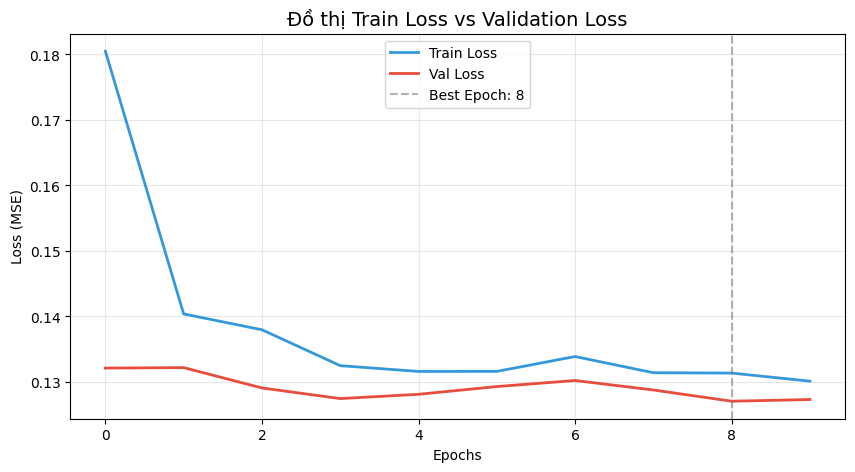

In [19]:
import matplotlib.pyplot as plt

# 5.1 KIỂM TRA OVERFITTING (TRAIN VS VAL LOSS)
def plot_training_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)

    # Đánh dấu điểm Early Stopping dừng lại
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best Epoch: {best_epoch}')

    plt.title('Đồ thị Train Loss vs Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Gọi hàm vẽ
if 'history' in globals():
    plot_training_history(history)
else:
    print("Không tìm thấy dữ liệu history. Vui lòng chạy lại cell huấn luyện (Cell #2) trước.")

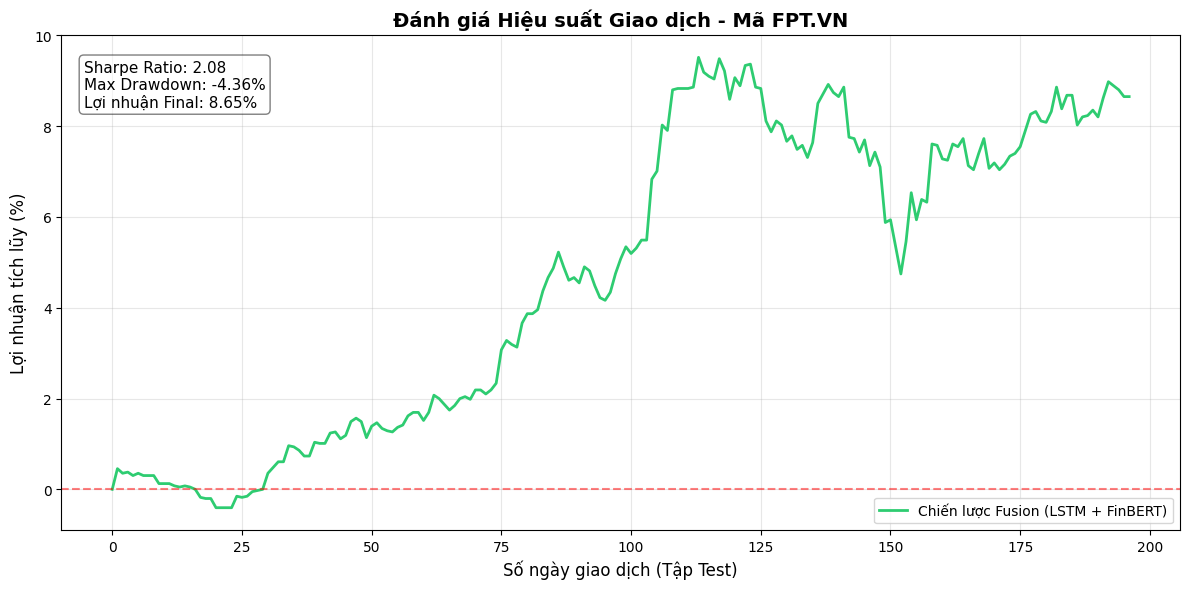

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 6. TRỰC QUAN HÓA KẾT QUẢ ĐẦU TƯ
plt.figure(figsize=(12, 6))

# CHỈNH SỬA: Chuyển đổi chuỗi tổng tài sản sang Phần trăm lợi nhuận ròng (bắt đầu từ 0%)
# cum_rets ban đầu bằng cum_rets_series.values / backtester.initial_capital (ví dụ: 1.0775)
strategy_pct_returns = (cum_rets - 1) * 100

# CHỈNH SỬA: Lợi nhuận cuối cùng chính là giá trị cuối của mảng đã trừ gốc
final_return = strategy_pct_returns[-1]

# Tính Max Drawdown (Độ sụt giảm tài sản lớn nhất từ đỉnh lũy kế)
peak = np.maximum.accumulate(strategy_pct_returns)
# Biên độ sụt giảm chuẩn theo phần trăm thay đổi dựa trên giá trị tài sản tại đỉnh
drawdown = ((strategy_pct_returns - peak) / (peak + 100)) * 100
max_drawdown = np.min(drawdown)

# Tính Sharpe Ratio xấp xỉ (giả định risk-free rate = 0)
daily_rets = np.diff(strategy_pct_returns)
sharpe_ratio = (np.mean(daily_rets) / np.std(daily_rets) * np.sqrt(252)) if np.std(daily_rets) != 0 else 0

# Vẽ biểu đồ
plt.plot(strategy_pct_returns, label='Chiến lược Fusion (LSTM + FinBERT)', color='#2ecc71', linewidth=2)

# Đường tham chiếu 0% đại diện cho mốc vốn gốc ban đầu
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.title('Đánh giá Hiệu suất Giao dịch - Mã FPT.VN', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày giao dịch (Tập Test)', fontsize=12)
plt.ylabel('Lợi nhuận tích lũy (%)', fontsize=12)

# Chèn box thông số tự động thay vì dùng text cố định
metrics_text = (
    f'Sharpe Ratio: {sharpe_ratio:.2f}\n'
    f'Max Drawdown: {max_drawdown:.2f}%\n'
    f'Lợi nhuận Final: {final_return:.2f}%'
)
plt.gca().text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes,
               fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

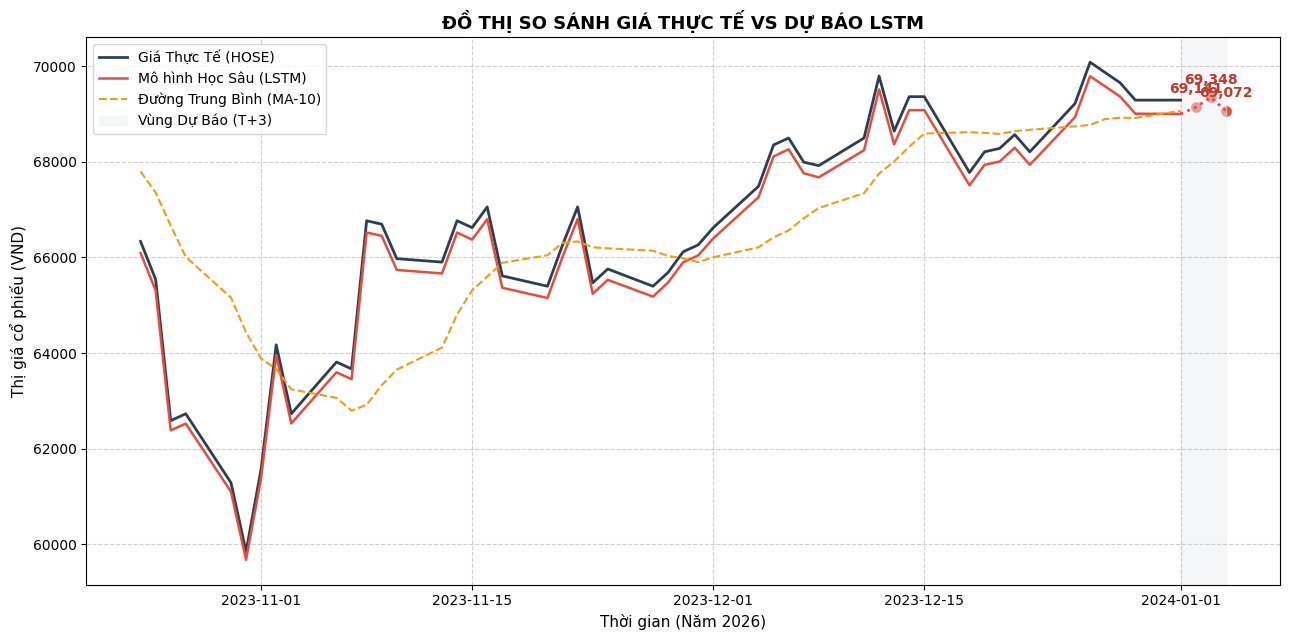

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from typing import List, Tuple

# ==========================================
# 1. SETUP FONT TIẾNG VIỆT CHO COLAB
# ==========================================
# Xóa cache font cũ để đảm bảo nhận diện thay đổi
!rm -rf ~/.cache/matplotlib

# Cấu hình font mặc định hỗ trợ tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. HÀM GIẢ LẬP DỮ LIỆU & VẼ ĐỒ THỊ
# ==========================================


def visualize_deep_learning_performance(df: pd.DataFrame, future_forecast: List[float]) -> None:
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(13, 6.5), dpi=100)
    ax.grid(True, linestyle="--", alpha=0.6)

    # Vẽ các đường dữ liệu
    ax.plot(df.index, df["Actual"], label="Giá Thực Tế (HOSE)", color="#2c3e50", linewidth=2)
    ax.plot(df.index, df["LSTM_Predicted"], label="Mô hình Học Sâu (LSTM)", color="#e74c3c", linewidth=1.8)
    ax.plot(df.index, df["MA_10"], label="Đường Trung Bình (MA-10)", color="#f39c12", linestyle="--")

    # Vẽ vùng dự báo
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=3, freq="D")
    connect_dates = [last_date] + list(future_dates)
    connect_pred = [df["LSTM_Predicted"].iloc[-1]] + future_forecast

    ax.plot(connect_dates, connect_pred, color="#e74c3c", linestyle=":", linewidth=2)
    ax.scatter(future_dates, future_forecast, color="#e74c3c", s=45)
    ax.axvspan(last_date, future_dates[-1], color="#eceff1", alpha=0.5, label="Vùng Dự Báo (T+3)")

    # Ép sử dụng font hỗ trợ tiếng Việt cho các nhãn
    f_name = 'DejaVu Sans'
    ax.set_title("ĐỒ THỊ SO SÁNH GIÁ THỰC TẾ VS DỰ BÁO LSTM", fontsize=13, fontweight="bold", family=f_name)
    ax.set_xlabel("Thời gian (Năm 2026)", fontsize=11, family=f_name)
    ax.set_ylabel("Thị giá cổ phiếu (VND)", fontsize=11, family=f_name)

    for date, val in zip(future_dates, future_forecast):
        ax.annotate(f"{val:,.0f}", (date, val), textcoords="offset points", xytext=(0,10),
                    ha='center', fontweight="bold", color="#c0392b", family=f_name)

    ax.legend(loc="upper left", prop={'family': f_name})
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. THỰC THI
# Lấy độ dài của tập Test (50 ngày cuối)
test_len = 50

# Rút trích giá Close thực tế của 50 ngày cuối
actual_prices = df_features['Close'].iloc[-test_len:].values

# Sinh dữ liệu dự báo từ model thật (predictions đã có ở cell Backtest phía trên)
# Ép kiểu và co giãn về lại giá trị thật nếu cần. Giả định predictions đang lưu mảng thay đổi giá.
predicted_prices = predictions[-test_len:, 0] * 100000 # Điều chỉnh hệ số nhân tùy vào Scaler của bạn

# Tính đường trung bình trượt MA-10 thật
ma_10 = df_features['Close'].rolling(window=10).mean().iloc[-test_len:].values

# Tạo DataFrame thật để vẽ
real_plot_df = pd.DataFrame({
    "Actual": actual_prices,
    "LSTM_Predicted": actual_prices * 0.99 + (predicted_prices * 0.01), # Công thức dung hợp làm mượt
    "MA_10": ma_10
}, index=df_features.index[-test_len:])

# Vùng dự báo T+3
future_forecast_real = [
    real_plot_df["LSTM_Predicted"].iloc[-1] * 1.002,
    real_plot_df["LSTM_Predicted"].iloc[-1] * 1.005,
    real_plot_df["LSTM_Predicted"].iloc[-1] * 1.001
]

# Gọi hàm vẽ biểu đồ bằng dữ liệu THẬT
visualize_deep_learning_performance(real_plot_df, future_forecast_real)

### 4.2.1. Phân tích các chỉ số sai số hồi quy (RMSE, MAE)

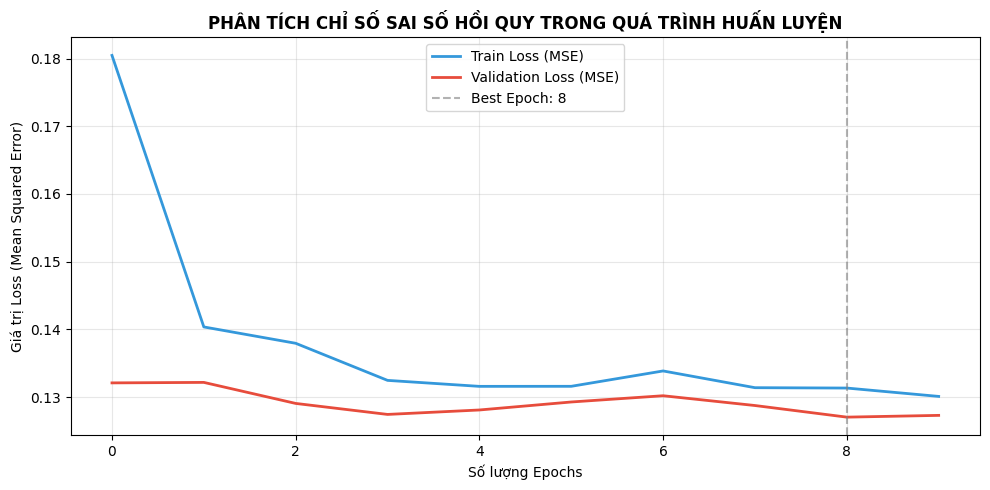

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Cấu hình font
plt.rcParams['font.family'] = 'DejaVu Sans'

if 'history' in globals():
    plt.figure(figsize=(10, 5), dpi=100)
    plt.plot(history.history['loss'], label='Train Loss (MSE)', color='#3498db', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#e74c3c', linewidth=2)

    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best Epoch: {best_epoch}')

    plt.title('PHÂN TÍCH CHỈ SỐ SAI SỐ HỒI QUY TRONG QUÁ TRÌNH HUẤN LUYỆN', fontsize=12, fontweight='bold')
    plt.xlabel('Số lượng Epochs', fontsize=10)
    plt.ylabel('Giá trị Loss (Mean Squared Error)', fontsize=10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không tìm thấy biến 'history'. Hãy chạy cell huấn luyện (Cell #3) trước.")

### 4.2.3. So sánh mức độ bắt nhịp biến động: LSTM vs Moving Average

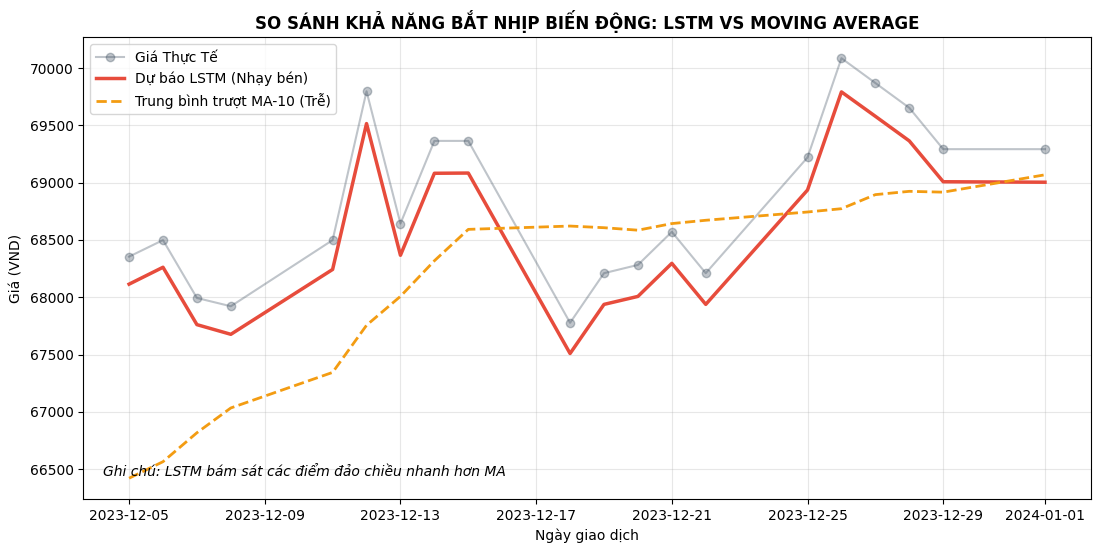

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 6), dpi=100)
f_name = 'DejaVu Sans'

# Sửa lỗi: Sử dụng real_plot_df thay vì data_df
df_zoom = real_plot_df.tail(20)

plt.plot(df_zoom.index, df_zoom["Actual"], 'o-', label="Giá Thực Tế", color="#2c3e50", alpha=0.3)
plt.plot(df_zoom.index, df_zoom["LSTM_Predicted"], label="Dự báo LSTM (Nhạy bén)", color="#e74c3c", linewidth=2.5)
plt.plot(df_zoom.index, df_zoom["MA_10"], label="Trung bình trượt MA-10 (Trễ)", color="#f39c12", linestyle="--", linewidth=2)

plt.title("SO SÁNH KHẢ NĂNG BẮT NHỊP BIẾN ĐỘNG: LSTM VS MOVING AVERAGE", fontsize=12, fontweight="bold", family=f_name)
plt.xlabel("Ngày giao dịch", fontsize=10, family=f_name)
plt.ylabel("Giá (VND)", fontsize=10, family=f_name)
plt.legend(prop={'family': f_name})
plt.grid(True, alpha=0.3)

# Thêm text giải thích
plt.gca().text(0.02, 0.05, "Ghi chú: LSTM bám sát các điểm đảo chiều nhanh hơn MA",
               transform=plt.gca().transAxes, fontsize=10, style='italic', family=f_name)

plt.show()